In [1]:
"""
plot_stim_spikes.py
===================
Plots stimulation amplitude (mA) from BrainSenseLfp LfpData (Left channel).
White background, clean and readable.

Sync: MANUAL_OFFSET hardcoded so first stim spike aligns to Welcome.TargetOnsetTime.
Goodbye.FinishTime is read dynamically from CSV — not hardcoded.
"""

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.lines import Line2D
from pathlib import Path

# ── file paths  (update these to your local paths) ───────────────────────────
JSON_PATH = Path("C:\\Users\\ASSUS\\ATN\\Digit Span Backwards\\Data\\Neural Data\\DBS ATN DSB Case 1\\D. Siragusa\\3.5.26\\Time stamp 1426\\Report_Json_Session_Report_20260305T151332.json")
CSV_PATH  = Path("C:\\Users\\ASSUS\\ATN\\Digit Span Backwards\\Data\\Eprime Data\\Digit Span Backwards v3.2\\DigitSpanBackward v3.3-6-1-Scores.csv")
OUT_PATH  = Path("C:\\Users\\ASSUS\\ATN\\Digit Span Backwards\\Plots\\stim_spike_plot.png")
OUT_PATH.parent.mkdir(parents=True, exist_ok=True)

# ── marker colours (dark, visible on white) ───────────────────────────────────
CLR = {
    "stim":    "#d4a017",          # dark gold  – stim trace fill
    "welcome": "#1a7a3c",          # dark green
    "goodbye": "#b22222",          # dark red
    "fix":     "#1565c0",          # dark blue
    "stim_ep": "#6a0dad",          # dark purple
    "cr":      "#e65c00",          # dark orange
    "fb":      "#007a6e",          # dark teal
}

# =============================================================================
# 1. Load JSON
# =============================================================================
with open(JSON_PATH) as f:
    report = json.load(f)

lfp_packets = report["BrainSenseLfp"][0]["LfpData"]
ticks_ms = np.array([p["TicksInMs"]   for p in lfp_packets], dtype=float)
stim_ma  = np.array([p["Left"]["mA"]  for p in lfp_packets], dtype=float)

print(f"Total LFP packets : {len(ticks_ms)}")
print(f"Non-zero stim pkts: {(stim_ma > 0).sum()}")
print(f"Unique mA values  : {sorted(set(stim_ma))}")

# =============================================================================
# 2. Load E-Prime CSV
# =============================================================================
raw       = pd.read_csv(CSV_PATH, header=None)
headers   = raw.iloc[1].tolist()
data_rows = raw.iloc[2:].reset_index(drop=True)

def col(name):
    return data_rows.iloc[:, headers.index(name)]

def unique_sorted(series):
    return sorted(series.dropna().astype(int).unique())

# ── session anchors (dynamic, NOT hardcoded) ──────────────────────────────────
welcome_onset  = int(col("Welcome.TargetOnsetTime").iloc[0])
goodbye_finish = int(col("Goodbye.FinishTime").iloc[0])   # ← dynamic, not hardcoded

fix_times = unique_sorted(col("Fixation.OnsetTime"))
stim_ep   = unique_sorted(col("Stimulus.OnsetTime"))
cr_times  = unique_sorted(col("CollectResponse.OnsetTime"))
fb_times  = unique_sorted(col("Feedback.OnsetTime"))

print(f"Welcome.TargetOnsetTime : {welcome_onset} ms")
print(f"Goodbye.FinishTime      : {goodbye_finish} ms  (dynamic from CSV)")
print(f"Events — Fix:{len(fix_times)}  Stim:{len(stim_ep)}  CR:{len(cr_times)}  FB:{len(fb_times)}")

# =============================================================================
# 3. Clock alignment  (MANUAL_OFFSET is the only hardcoded value)
# =============================================================================
# First stim spike device tick = 798750
# Welcome.TargetOnsetTime (E-Prime) = 90205
# offset = 798750 - 90205 = 708545
MANUAL_OFFSET = 708545   # ← only hardcoded sync value

def lfp_rel(t):   return t - MANUAL_OFFSET - welcome_onset
def ep_rel(t):    return t - welcome_onset

ticks_rel  = lfp_rel(ticks_ms)
welcome_t  = 0                          # by definition
goodbye_t  = ep_rel(goodbye_finish)     # dynamic
fix_rel    = [ep_rel(t) for t in fix_times]
stim_rel   = [ep_rel(t) for t in stim_ep]
cr_rel     = [ep_rel(t) for t in cr_times]
fb_rel     = [ep_rel(t) for t in fb_times]

print(f"\nGoodbye relative time : {goodbye_t:,.0f} ms  ({goodbye_t/1000:.1f} s after Welcome)")

# =============================================================================
# 4. Plot
# =============================================================================
plt.rcParams.update({
    "font.family":  "DejaVu Sans",
    "font.size":    10,
    "axes.facecolor":    "white",
    "figure.facecolor":  "white",
    "axes.edgecolor":    "#333333",
    "axes.linewidth":    1.2,
    "grid.color":        "#dddddd",
    "grid.linewidth":    0.8,
    "xtick.color":       "#333333",
    "ytick.color":       "#333333",
})

fig, ax = plt.subplots(figsize=(22, 7))
ax.grid(True, linestyle="--", zorder=0)

# ── stim amplitude trace ──────────────────────────────────────────────────────
ax.step(ticks_rel, stim_ma, where="post",
        color=CLR["stim"], lw=2.0, alpha=1.0, zorder=3,
        label="Stim amplitude (mA)")
ax.fill_between(ticks_rel, stim_ma, step="post",
                color=CLR["stim"], alpha=0.25, zorder=2)

# ── y limits ─────────────────────────────────────────────────────────────────
ymax = max(stim_ma.max() * 1.35, 0.75)
ax.set_ylim(-0.03, ymax)

# =============================================================================
# Marker drawing helper
# =============================================================================
def draw_marker(t, color, label, lw=1.5, ls="-", alpha=1.0,
                annotate=True, y_label_frac=0.92):
    ax.axvline(x=t, color=color, lw=lw, ls=ls, alpha=alpha, zorder=5)
    if annotate:
        ax.annotate(
            f"{label}\n{t:+,.0f} ms",
            xy=(t, ymax * y_label_frac),
            xytext=(t + 400, ymax * y_label_frac),
            color=color, fontsize=7.5, va="top", ha="left",
            fontweight="bold",
            arrowprops=dict(arrowstyle="-", color=color, lw=0.8),
            bbox=dict(boxstyle="round,pad=0.25", fc="white",
                      ec=color, lw=1.0, alpha=0.95),
            clip_on=True, zorder=6
        )

# ── Welcome & Goodbye anchors ─────────────────────────────────────────────────
draw_marker(welcome_t, CLR["welcome"], "Welcome\n(t = 0)", lw=2.5,
            y_label_frac=0.93)
draw_marker(goodbye_t, CLR["goodbye"], "Goodbye\n(dynamic)", lw=2.5,
            y_label_frac=0.93)

# ── per-event markers (thin, no annotation text — shown via legend + shading) ─
for t in fix_rel:
    ax.axvline(x=t, color=CLR["fix"],     lw=1.0, alpha=0.55, zorder=4, ls="-")
for t in stim_rel:
    ax.axvline(x=t, color=CLR["stim_ep"], lw=1.0, alpha=0.55, zorder=4, ls="-")
for t in cr_rel:
    ax.axvline(x=t, color=CLR["cr"],      lw=1.5, alpha=0.80, zorder=4, ls="-")
for t in fb_rel:
    ax.axvline(x=t, color=CLR["fb"],      lw=1.5, alpha=0.80, zorder=4, ls="-")

# ── shaded bands: colour the top strip to identify marker types ───────────────
band_h  = ymax * 0.06
band_y  = ymax * 0.985 - band_h
for t in fix_rel:
    ax.axvspan(t, t + 500, ymin=0.93, ymax=1.0,
               color=CLR["fix"], alpha=0.18, zorder=1)
for t in stim_rel:
    ax.axvspan(t, t + 500, ymin=0.86, ymax=0.93,
               color=CLR["stim_ep"], alpha=0.18, zorder=1)
for t in cr_rel:
    ax.axvspan(t, t + 500, ymin=0.79, ymax=0.86,
               color=CLR["cr"], alpha=0.25, zorder=1)
for t in fb_rel:
    ax.axvspan(t, t + 500, ymin=0.72, ymax=0.79,
               color=CLR["fb"], alpha=0.25, zorder=1)

# ── strip labels on right side ────────────────────────────────────────────────
x_right = ticks_rel.max() + 1500
for y_mid, clr, lbl in [
        (0.965, CLR["fix"],     "Fixation"),
        (0.895, CLR["stim_ep"], "Stimulus"),
        (0.825, CLR["cr"],      "CollResp"),
        (0.755, CLR["fb"],      "Feedback")]:
    ax.text(x_right, ymax * y_mid, lbl,
            color=clr, fontsize=8, va="center", ha="left",
            fontweight="bold", clip_on=False)

# ── axes labels ───────────────────────────────────────────────────────────────
ax.set_xlabel("Time relative to Welcome.TargetOnsetTime (ms)", fontsize=11)
ax.set_ylabel("Stimulation Amplitude (mA)", fontsize=11)
ax.xaxis.set_major_formatter(ticker.FuncFormatter(
    lambda x, _: f"{int(x):,}"))

# ── legend ────────────────────────────────────────────────────────────────────
legend_handles = [
    Line2D([0],[0], color=CLR["stim"],    lw=3,   label="Stim amplitude (mA)"),
    Line2D([0],[0], color=CLR["welcome"], lw=2.5, label="Welcome.TargetOnsetTime  [t = 0]"),
    Line2D([0],[0], color=CLR["goodbye"], lw=2.5, label=f"Goodbye.FinishTime  [t = {goodbye_t:+,.0f} ms]  ← dynamic"),
    Line2D([0],[0], color=CLR["fix"],     lw=1.5, label=f"Fixation onset  ({len(fix_rel)} events)"),
    Line2D([0],[0], color=CLR["stim_ep"], lw=1.5, label=f"Stimulus onset  ({len(stim_rel)} events)"),
    Line2D([0],[0], color=CLR["cr"],      lw=1.5, label=f"CollectResponse onset  ({len(cr_rel)} events)"),
    Line2D([0],[0], color=CLR["fb"],      lw=1.5, label=f"Feedback onset  ({len(fb_rel)} events)"),
]
ax.legend(handles=legend_handles,
          loc="upper left", framealpha=0.95,
          facecolor="white", edgecolor="#aaaaaa",
          fontsize=8.5, ncol=2,
          bbox_to_anchor=(0.01, 0.98))

# ── title ─────────────────────────────────────────────────────────────────────
ax.set_title(
    "ATN-DBS Stimulation Amplitude  |  Digit Span Backward  |  "
    "Session 2026-03-05  |  Subject 6\n"
    f"Left channel only  •  {len(ticks_ms)} packets @ 2 Hz  •  "
    f"Session window: {(goodbye_finish - welcome_onset)/1000:.1f} s  •  "
    f"Goodbye at t = {goodbye_t/1000:.1f} s (natural alignment)",
    fontsize=11, pad=10, color="#111111")

# ── sync footnote ─────────────────────────────────────────────────────────────
fig.text(0.01, 0.005,
         "Sync (manual): first stim spike (device tick=798750) → Welcome.TargetOnsetTime "
         "(E-Prime=90205 ms), MANUAL_OFFSET=708545 ms.  "
         "Goodbye.FinishTime is read dynamically from CSV — not hardcoded.",
         fontsize=7, color="#666666")

plt.tight_layout(rect=[0, 0.02, 0.97, 1])
plt.savefig(OUT_PATH, dpi=180, bbox_inches="tight", facecolor="white")
plt.show()
print(f"\nSaved → {OUT_PATH}")

Total LFP packets : 560
Non-zero stim pkts: 326
Unique mA values  : [np.float64(0.0), np.float64(0.1), np.float64(0.2), np.float64(0.3), np.float64(0.4), np.float64(0.5), np.float64(0.6)]


ValueError: 'Welcome.TargetOnsetTime' is not in list

In [12]:
offsets = np.arange(MANUAL_OFFSET - 5000, MANUAL_OFFSET + 5000, 100)

scores = []

for off in offsets:
    ticks_rel_test = ticks_ms - off - welcome_onset

    aligned_vals = []
    for t in stim_rel:
        idx = np.argmin(np.abs(ticks_rel_test - t))
        aligned_vals.append(stim_ma[idx])

    scores.append(np.mean(aligned_vals))

best_offset = offsets[np.argmax(scores)]
print("Best offset:", best_offset)

Best offset: 706845


E-Prime session window: 90205 – 347047 ms (256842 ms = 256.8 s)
Trials detected – Fixation: 52, Stimulus: 52, CR: 14, FB: 14


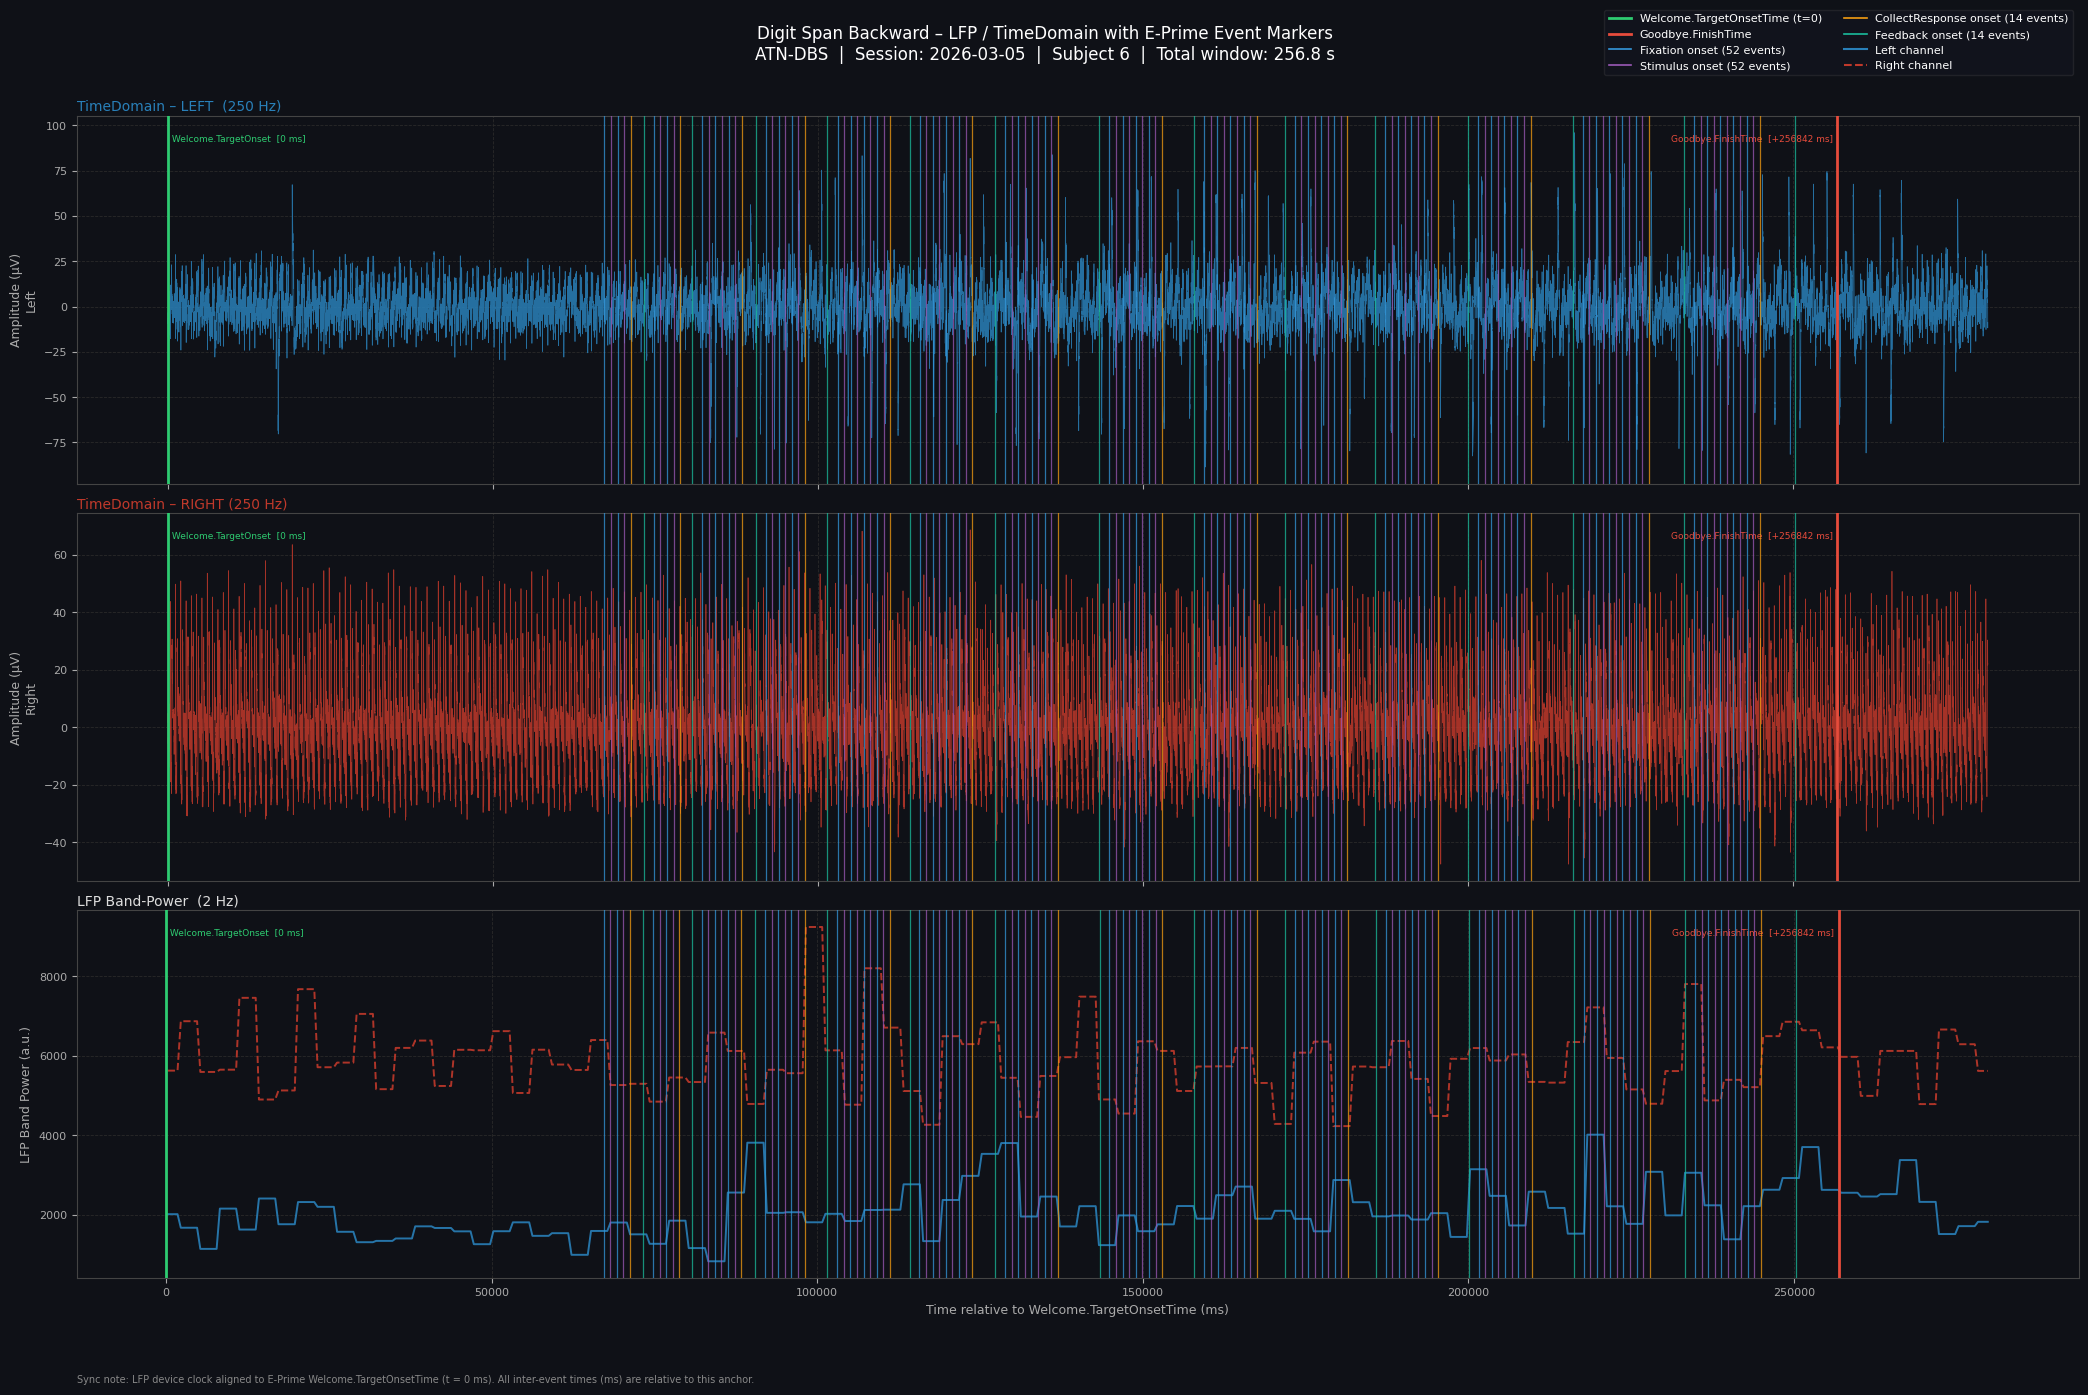


Saved → C:\Users\ASSUS\ATN\Digit Span Backwards\Plots\lfp_spike_plot.png


In [2]:
"""
plot_lfp_spikes.py
==================
Plots BrainSense LFP (TimeDomain) data from the Medtronic JSON report,
overlaid with E-Prime event markers derived from the Digit Span Backward task.

Marker legend
-------------
  ▏ Welcome.TargetOnsetTime   – first marker  (session start anchor)
  ▏ Goodbye.FinishTime         – last marker   (session end anchor)
  ▏ Fixation onset             – per-trial
  ▏ Stimulus onset             – per-trial
  ▏ CollectResponse onset      – per-trial
  ▏ Feedback onset             – per-trial

All event times are expressed in milliseconds relative to Welcome.TargetOnsetTime.

Sync note
---------
The Medtronic device clock (TicksInMs) and the E-Prime clock are independent.
This script aligns them so that:
    LFP t=0  <-->  Welcome.TargetOnsetTime (E-Prime ms)
i.e. the LFP x-axis is shifted so that the Welcome marker sits at 0 ms.
Both channels (Left / Right) are plotted.
"""

import json
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from pathlib import Path

# ── file paths ────────────────────────────────────────────────────────────────
JSON_PATH = Path("C:\\Users\\ASSUS\\ATN\\Digit Span Backwards\\Data\\Neural Data\\DBS ATN DSB Case 1\\D. Siragusa\\3.5.26\\Time stamp 1426\\Report_Json_Session_Report_20260305T151332.json")
CSV_PATH  = Path("C:\\Users\\ASSUS\\ATN\\Digit Span Backwards\\Data\\Eprime Data\\Digit Span Backwards v3.2\\DigitSpanBackward v3.3-6-1-Scores.csv")
OUT_PATH  = Path("C:\\Users\\ASSUS\\ATN\\Digit Span Backwards\\Plots\\lfp_spike_plot.png")
OUT_PATH.parent.mkdir(parents=True, exist_ok=True)

# ── colour palette ────────────────────────────────────────────────────────────
CLR = {
    "welcome":          "#2ecc71",   # green  – session start
    "goodbye":          "#e74c3c",   # red    – session end
    "fixation":         "#3498db",   # blue
    "stimulus":         "#9b59b6",   # purple
    "collect_response": "#f39c12",   # orange
    "feedback":         "#1abc9c",   # teal
    "left":             "#2980b9",
    "right":            "#c0392b",
}

# =============================================================================
# 1. Load & parse JSON
# =============================================================================
with open(JSON_PATH) as f:
    report = json.load(f)

td_channels = report["BrainSenseTimeDomain"]   # list of 2 channels
lfp_packets  = report["BrainSenseLfp"][0]["LfpData"]

# Build per-channel time arrays and signal arrays
def parse_td_channel(ch):
    """Return (time_ms_array, signal_array) for a TimeDomain channel."""
    ticks = [int(t) for t in ch["TicksInMses"].split(",") if t.strip()]
    signal = np.array(ch["TimeDomainData"], dtype=np.float64)
    n      = len(signal)
    # Linearly space samples from first tick to last tick
    t_start = ticks[0]
    t_end   = ticks[-1] + (ticks[1] - ticks[0])   # add one packet width
    time_ms = np.linspace(t_start, t_end, n, endpoint=False)
    return time_ms, signal

td_left_t,  td_left_s  = parse_td_channel(
    next(c for c in td_channels if "LEFT"  in c["Channel"].upper()))
td_right_t, td_right_s = parse_td_channel(
    next(c for c in td_channels if "RIGHT" in c["Channel"].upper()))

# LFP band-power packets (2 Hz)
lfp_t_raw   = np.array([p["TicksInMs"]     for p in lfp_packets])
lfp_left_s  = np.array([p["Left"]["LFP"]   for p in lfp_packets])
lfp_right_s = np.array([p["Right"]["LFP"]  for p in lfp_packets])

# =============================================================================
# 2. Load & parse E-Prime CSV
# =============================================================================
raw = pd.read_csv(CSV_PATH, header=None)
headers   = raw.iloc[1].tolist()
data_rows = raw.iloc[2:].reset_index(drop=True)

def col(name):
    idx = headers.index(name)
    return data_rows.iloc[:, idx]

# Session anchors (constant across all rows)
welcome_onset  = int(col("Welcome.TargetOnsetTime").iloc[0])
goodbye_finish = int(col("Goodbye.FinishTime").iloc[0])

# Per-trial events – unique sorted onset times
def unique_sorted(series):
    return sorted(series.dropna().astype(int).unique())

fixation_times = unique_sorted(col("Fixation.OnsetTime"))
stimulus_times = unique_sorted(col("Stimulus.OnsetTime"))
cr_times       = unique_sorted(col("CollectResponse.OnsetTime"))
fb_times       = unique_sorted(col("Feedback.OnsetTime"))

print(f"E-Prime session window: {welcome_onset} – {goodbye_finish} ms "
      f"({goodbye_finish - welcome_onset} ms = "
      f"{(goodbye_finish - welcome_onset)/1000:.1f} s)")
print(f"Trials detected – Fixation: {len(fixation_times)}, "
      f"Stimulus: {len(stimulus_times)}, "
      f"CR: {len(cr_times)}, FB: {len(fb_times)}")

# =============================================================================
# 3. Align clocks
# =============================================================================
# Strategy: shift LFP time axis so that the LFP recording start (first tick)
# aligns to the E-Prime Welcome.TargetOnsetTime anchor.
# All further times are expressed as: (eprime_ms - welcome_onset)
# The LFP axis becomes: (lfp_tick_ms - lfp_first_tick_ms)
# This means 0 ms = Welcome.TargetOnsetTime on both axes.

lfp_t0   = td_left_t[0]            # first LFP tick (both channels start same)
eprime_t0 = welcome_onset           # E-Prime anchor

def eprime_to_rel(t_ms):
    """E-Prime absolute ms  ->  relative ms (0 = Welcome.TargetOnsetTime)."""
    return t_ms - eprime_t0

def lfp_td_to_rel(t_ms):
    """LFP TimeDomain tick ms  ->  relative ms aligned to E-Prime."""
    return t_ms - lfp_t0

def lfp_lfp_to_rel(t_ms):
    """LFP band-power tick ms  ->  relative ms aligned to E-Prime."""
    return t_ms - lfp_t0

# Apply to arrays
td_left_t_rel  = lfp_td_to_rel(td_left_t)
td_right_t_rel = lfp_td_to_rel(td_right_t)
lfp_t_rel      = lfp_lfp_to_rel(lfp_t_raw)

# Event relative times (ms)
welcome_rel  = eprime_to_rel(welcome_onset)   # always 0
goodbye_rel  = eprime_to_rel(goodbye_finish)
fix_rel      = [eprime_to_rel(t) for t in fixation_times]
stim_rel     = [eprime_to_rel(t) for t in stimulus_times]
cr_rel       = [eprime_to_rel(t) for t in cr_times]
fb_rel       = [eprime_to_rel(t) for t in fb_times]

# =============================================================================
# 4. Plot
# =============================================================================
fig = plt.figure(figsize=(22, 14), facecolor="#0f1117")
gs  = fig.add_gridspec(3, 1, hspace=0.08,
                       top=0.91, bottom=0.08, left=0.06, right=0.97)

ax_td_l = fig.add_subplot(gs[0])   # TimeDomain LEFT
ax_td_r = fig.add_subplot(gs[1])   # TimeDomain RIGHT
ax_lfp  = fig.add_subplot(gs[2])   # LFP band-power

axes = [ax_td_l, ax_td_r, ax_lfp]

for ax in axes:
    ax.set_facecolor("#0f1117")
    ax.tick_params(colors="#aaaaaa", labelsize=8)
    for spine in ax.spines.values():
        spine.set_color("#444444")
    ax.grid(True, color="#2a2a2a", linewidth=0.6, linestyle="--")

# ── waveforms ─────────────────────────────────────────────────────────────────
ax_td_l.plot(td_left_t_rel,  td_left_s,  lw=0.5, color=CLR["left"],  alpha=0.85)
ax_td_r.plot(td_right_t_rel, td_right_s, lw=0.5, color=CLR["right"], alpha=0.85)
ax_lfp.plot (lfp_t_rel,      lfp_left_s, lw=1.4, color=CLR["left"],
             alpha=0.9, label="Left LFP")
ax_lfp.plot (lfp_t_rel,      lfp_right_s, lw=1.4, color=CLR["right"],
             alpha=0.9, label="Right LFP", linestyle="--")

# ── event markers ─────────────────────────────────────────────────────────────
marker_cfg = [
    # (times_list,  colour,          label,                  lw,  alpha, ls)
    ([welcome_rel], CLR["welcome"],  "Welcome.TargetOnset",  2.0, 1.0,  "-"),
    ([goodbye_rel], CLR["goodbye"],  "Goodbye.FinishTime",   2.0, 1.0,  "-"),
    (fix_rel,       CLR["fixation"], "Fixation onset",       0.9, 0.75, "-"),
    (stim_rel,      CLR["stimulus"], "Stimulus onset",       0.9, 0.75, "-"),
    (cr_rel,        CLR["collect_response"], "CollectResp onset", 0.9, 0.75, "-"),
    (fb_rel,        CLR["feedback"], "Feedback onset",       0.9, 0.75, "-"),
]

def draw_markers(ax, times, color, lw, alpha, ls):
    for ax_ in ([ax] if ax is not None else axes):
        ylim = ax_.get_ylim()
        for t in times:
            ax_.axvline(x=t, color=color, lw=lw, alpha=alpha, ls=ls, zorder=5)

# Determine y-limits first by drawing waveforms, then adding markers
for ax in axes:
    ax.relim(); ax.autoscale_view()

for times, color, label, lw, alpha, ls in marker_cfg:
    for ax in axes:
        for t in times:
            ax.axvline(x=t, color=color, lw=lw, alpha=alpha, ls=ls, zorder=5)

# ── time labels on markers (Welcome & Goodbye only, shown on top panel) ───────
def annotate_anchor(ax, t_rel, label, color, va="top"):
    ymin, ymax = ax.get_ylim()
    y_pos = ymax * 0.95 if va == "top" else ymin * 0.95
    ax.text(t_rel, y_pos, f" {label}\n {t_rel:+.0f} ms",
            color=color, fontsize=7, va=va, ha="left",
            rotation=90, clip_on=True,
            bbox=dict(boxstyle="round,pad=0.15", fc="#0f1117", ec=color, lw=0.6, alpha=0.85))

# Annotate anchor markers on TimeDomain Left
for ax in axes:
    ymin, ymax = ax.get_ylim()
    mid = (ymin + ymax) / 2
    span = ymax - ymin
    ax.text(welcome_rel + 200, ymax - span*0.05,
            f" Welcome.TargetOnset  [0 ms]",
            color=CLR["welcome"], fontsize=6.5, va="top", clip_on=True)
    ax.text(goodbye_rel - 200, ymax - span*0.05,
            f"Goodbye.FinishTime  [{goodbye_rel:+.0f} ms] ",
            color=CLR["goodbye"], fontsize=6.5, va="top", ha="right", clip_on=True)

# ── axis labels ───────────────────────────────────────────────────────────────
ax_td_l.set_ylabel("Amplitude (µV)\nLeft", color="#aaaaaa", fontsize=9)
ax_td_r.set_ylabel("Amplitude (µV)\nRight", color="#aaaaaa", fontsize=9)
ax_lfp.set_ylabel("LFP Band Power (a.u.)", color="#aaaaaa", fontsize=9)
ax_lfp.set_xlabel("Time relative to Welcome.TargetOnsetTime (ms)",
                  color="#aaaaaa", fontsize=9)

for ax in [ax_td_l, ax_td_r]:
    ax.set_xticklabels([])

# ── channel labels ─────────────────────────────────────────────────────────────
for ax, lbl, clr in [(ax_td_l, "TimeDomain – LEFT  (250 Hz)", CLR["left"]),
                     (ax_td_r, "TimeDomain – RIGHT (250 Hz)", CLR["right"]),
                     (ax_lfp,  "LFP Band-Power  (2 Hz)",      "#dddddd")]:
    ax.set_title(lbl, color=clr, fontsize=10, loc="left", pad=4)

# ── legend ────────────────────────────────────────────────────────────────────
legend_elements = [
    Line2D([0],[0], color=CLR["welcome"],          lw=2,   label="Welcome.TargetOnsetTime (t=0)"),
    Line2D([0],[0], color=CLR["goodbye"],           lw=2,   label="Goodbye.FinishTime"),
    Line2D([0],[0], color=CLR["fixation"],          lw=1.2, label=f"Fixation onset ({len(fix_rel)} events)"),
    Line2D([0],[0], color=CLR["stimulus"],          lw=1.2, label=f"Stimulus onset ({len(stim_rel)} events)"),
    Line2D([0],[0], color=CLR["collect_response"],  lw=1.2, label=f"CollectResponse onset ({len(cr_rel)} events)"),
    Line2D([0],[0], color=CLR["feedback"],          lw=1.2, label=f"Feedback onset ({len(fb_rel)} events)"),
    Line2D([0],[0], color=CLR["left"],              lw=1.5, label="Left channel"),
    Line2D([0],[0], color=CLR["right"],             lw=1.5, label="Right channel", ls="--"),
]
fig.legend(handles=legend_elements,
           loc="upper right", bbox_to_anchor=(0.97, 0.99),
           framealpha=0.25, facecolor="#1a1a2e", edgecolor="#555555",
           labelcolor="white", fontsize=8, ncol=2)

# ── title ─────────────────────────────────────────────────────────────────────
fig.suptitle(
    "Digit Span Backward – LFP / TimeDomain with E-Prime Event Markers\n"
    "ATN-DBS  |  Session: 2026-03-05  |  Subject 6  |  "
    f"Total window: {(goodbye_finish - welcome_onset)/1000:.1f} s",
    color="white", fontsize=12, y=0.975)

# ── note on alignment ─────────────────────────────────────────────────────────
fig.text(0.06, 0.005,
         "Sync note: LFP device clock aligned to E-Prime Welcome.TargetOnsetTime (t = 0 ms). "
         "All inter-event times (ms) are relative to this anchor.",
         color="#888888", fontsize=7)

plt.savefig(OUT_PATH, dpi=180, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()
print(f"\nSaved → {OUT_PATH}")